# Weather Condition Classification using Support Vector Machine (SVM)

## AI-ML Assignment – 6

**Objective:**  
Classify weather conditions as **Warm** or **Cool** using a Support Vector Machine (SVM) with weather data collected from the Open-Meteo API.

In [1]:
import requests
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

In [2]:
cities = [
    ("Delhi", 28.6139, 77.2090),
    ("Shimla", 31.1048, 77.1734),
    ("Leh", 34.1526, 77.5770),
    ("Mumbai", 19.0760, 72.8777),
    ("Bengaluru", 12.9716, 77.5946)
]

all_data = []

for city, lat, lon in cities:

    url = "https://api.open-meteo.com/v1/forecast"

    params = {
        "latitude": lat,
        "longitude": lon,
        "hourly": [
            "temperature_2m",
            "relative_humidity_2m",
            "surface_pressure",
            "wind_speed_10m"
        ],
        "forecast_days": 7
    }

    response = requests.get(url, params=params)
    weather = response.json()

    hourly = weather["hourly"]

    temp_df = pd.DataFrame({
        "City": city,
        "Time": hourly["time"],
        "Temperature": hourly["temperature_2m"],
        "Humidity": hourly["relative_humidity_2m"],
        "Pressure": hourly["surface_pressure"],
        "WindSpeed": hourly["wind_speed_10m"]
    })

    all_data.append(temp_df)

df = pd.concat(all_data, ignore_index=True)

df.head()

,City,Time,Temperature,Humidity,Pressure,WindSpeed
0,Delhi,2026-07-28T00:00,28.5,92,973.7,7.9
1,Delhi,2026-07-28T01:00,28.5,93,974.4,8.0
2,Delhi,2026-07-28T02:00,28.8,93,974.7,7.9
3,Delhi,2026-07-28T03:00,28.3,88,975.2,12.0
4,Delhi,2026-07-28T04:00,28.1,90,976.0,10.5


In [3]:
df["Weather_Class"] = np.where(
    df["Temperature"] >= 25,
    "Warm",
    "Cool"
)

df.head()

,City,Time,Temperature,Humidity,Pressure,WindSpeed,Weather_Class
0,Delhi,2026-07-28T00:00,28.5,92,973.7,7.9,Warm
1,Delhi,2026-07-28T01:00,28.5,93,974.4,8.0,Warm
2,Delhi,2026-07-28T02:00,28.8,93,974.7,7.9,Warm
3,Delhi,2026-07-28T03:00,28.3,88,975.2,12.0,Warm
4,Delhi,2026-07-28T04:00,28.1,90,976.0,10.5,Warm


In [4]:
df.to_csv("weather_data.csv", index=False)

print("Dataset saved successfully.")

Dataset saved successfully.


In [5]:
print("First Five Records")
display(df.head())

print("\nDataset Shape:", df.shape)

print("\nDataset Information")
df.info()

First Five Records


,City,Time,Temperature,Humidity,Pressure,WindSpeed,Weather_Class
0,Delhi,2026-07-28T00:00,28.5,92,973.7,7.9,Warm
1,Delhi,2026-07-28T01:00,28.5,93,974.4,8.0,Warm
2,Delhi,2026-07-28T02:00,28.8,93,974.7,7.9,Warm
3,Delhi,2026-07-28T03:00,28.3,88,975.2,12.0,Warm
4,Delhi,2026-07-28T04:00,28.1,90,976.0,10.5,Warm



Dataset Shape: (840, 7)

Dataset Information
<class 'pandas.DataFrame'>
RangeIndex: 840 entries, 0 to 839
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   City           840 non-null    str    
 1   Time           840 non-null    str    
 2   Temperature    840 non-null    float64
 3   Humidity       840 non-null    int64  
 4   Pressure       840 non-null    float64
 5   WindSpeed      840 non-null    float64
 6   Weather_Class  840 non-null    str    
dtypes: float64(3), int64(1), str(3)
memory usage: 67.3 KB


## Input Features

- Temperature
- Relative Humidity
- Surface Pressure
- Wind Speed

## Target Variable

Weather_Class

In [6]:
print("Missing Values")
print(df.isnull().sum())

Missing Values
City             0
Time             0
Temperature      0
Humidity         0
Pressure         0
WindSpeed        0
Weather_Class    0
dtype: int64


In [7]:
print(df["Weather_Class"].value_counts())

Weather_Class
Cool    449
Warm    391
Name: count, dtype: int64


In [8]:
df = df.drop(["City", "Time"], axis=1)

df.head()

,Temperature,Humidity,Pressure,WindSpeed,Weather_Class
0,28.5,92,973.7,7.9,Warm
1,28.5,93,974.4,8.0,Warm
2,28.8,93,974.7,7.9,Warm
3,28.3,88,975.2,12.0,Warm
4,28.1,90,976.0,10.5,Warm


In [9]:
encoder = LabelEncoder()

df["Weather_Class"] = encoder.fit_transform(df["Weather_Class"])

df.head()

,Temperature,Humidity,Pressure,WindSpeed,Weather_Class
0,28.5,92,973.7,7.9,1
1,28.5,93,974.4,8.0,1
2,28.8,93,974.7,7.9,1
3,28.3,88,975.2,12.0,1
4,28.1,90,976.0,10.5,1


In [10]:
X = df.drop("Weather_Class", axis=1)

y = df["Weather_Class"]

print(X.head())

print()

print(y.head())

   Temperature  Humidity  Pressure  WindSpeed
0         28.5        92     973.7        7.9
1         28.5        93     974.4        8.0
2         28.8        93     974.7        7.9
3         28.3        88     975.2       12.0
4         28.1        90     976.0       10.5

0    1
1    1
2    1
3    1
4    1
Name: Weather_Class, dtype: int64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

Training Shape: (672, 4)
Testing Shape: (168, 4)


In [12]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Feature Scaling Completed Successfully!")

Feature Scaling Completed Successfully!


In [13]:
svm_model = SVC(kernel="rbf", random_state=42)

svm_model.fit(X_train, y_train)

print("SVM Model Trained Successfully!")

SVM Model Trained Successfully!


In [14]:
y_pred = svm_model.predict(X_test)

print("First 10 Predictions:")

print(y_pred[:10])

First 10 Predictions:
[1 1 1 0 0 1 1 1 1 0]


In [15]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.9940476190476191
Precision: 0.9873417721518988
Recall   : 1.0
F1 Score : 0.9936305732484076


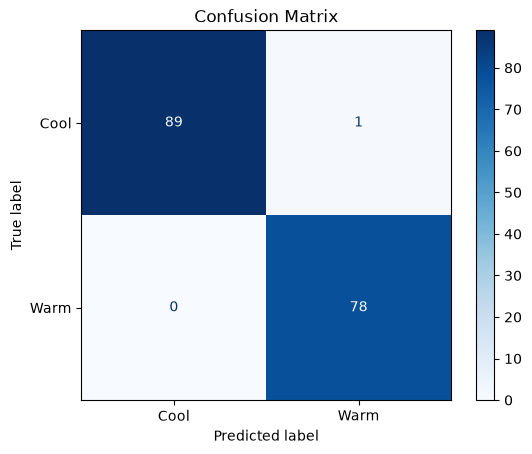

In [16]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=encoder.classes_
)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix")

plt.show()

## Observations

1. The SVM classifier successfully classified weather conditions into Warm and Cool categories with good accuracy.

2. Feature scaling using StandardScaler improved the model performance because SVM is sensitive to the scale of input features.

3. The confusion matrix shows that the model correctly classified most weather conditions, with only a few misclassifications.

## Conclusion

In this assignment, weather data was collected from the Open-Meteo API for multiple cities and used to classify weather conditions as Warm or Cool using a Support Vector Machine (SVM). The meteorological features, including temperature, humidity, surface pressure, and wind speed, were preprocessed and standardized before model training. The trained SVM model demonstrated effective classification performance on the testing dataset. Feature scaling played an important role because SVM is sensitive to the range of input values, resulting in improved model performance. One major advantage of SVM is its ability to classify complex data with high accuracy, while one limitation is that it can become computationally expensive when working with very large datasets.